# Percobaan Menurunkan Ambang untuk Menaikkan Recall

**Tanggal kegiatan: 21 Juli 2026**

Evaluasi dua hari lalu menghasilkan recall 0,493 pada ambang F1 terbaik (0,705).
Artinya 38 dari 75 penderita tidak menerima peringatan apa pun.

Pertanyaan yang harus dijawab hari ini: **kalau ambangnya diturunkan supaya lebih
banyak penderita tertangkap, berapa harganya?** Menurunkan ambang berarti model
lebih mudah menandai seseorang berisiko, sehingga orang sehat pun ikut tertandai.

Notebook ini mencari angka ambang yang tepat, bukan menebaknya.

In [1]:
import warnings, sys
warnings.simplefilter("ignore")
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import joblib

from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import (
    confusion_matrix, f1_score, fbeta_score, precision_score,
    recall_score, roc_auc_score,
)
from model.train import (
    load_dataset, FEATURE_ORDER, RANDOM_STATE, CV,
    _ordinal_encode_for_xgb, best_f1_threshold, recall_target_threshold, TARGET_RECALL,
)

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

df = load_dataset()
X, y = df[FEATURE_ORDER], df["stroke"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
model = joblib.load("artifacts/stroke_risk_model.joblib")["model"]
Xtr_e, Xte_e = _ordinal_encode_for_xgb(X_train), _ordinal_encode_for_xgb(X_test)
proba = model.predict_proba(Xte_e)[:, 1]
tot = int(y_test.sum())
print(f"Data uji: {len(y_test):,} orang, {tot} di antaranya kena stroke")

Data uji: 1,533 orang, 75 di antaranya kena stroke


## 1. Percobaan Pertama: Turunkan Saja Sampai Recall Sempurna

Percobaan paling sederhana lebih dulu. Kalau ambang diturunkan terus sampai
seluruh 75 penderita tertangkap, apa yang terjadi?

In [2]:
amb_semua = None
for th in np.linspace(0.999, 0.001, 2000):
    if int(((proba >= th) & (y_test == 1)).sum()) == tot:
        amb_semua = th; break

yp = (proba >= amb_semua).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, yp).ravel()

print("PERCOBAAN: ambang diturunkan sampai recall 1,0")
print()
print(f"  Ambang yang dibutuhkan : {amb_semua:.4f}")
print(f"  Penderita terdeteksi   : {tp} dari {tot}  (recall 1,000)")
print(f"  Penderita terlewat     : {fn}")
print(f"  Salah positif          : {fp} dari {tn+fp} orang sehat")
print(f"  Orang sehat lolos      : {tn}")
print(f"  Presisi                : {precision_score(y_test, yp, zero_division=0):.4f}")
print()
print("GAGAL. Model menandai SELURUH orang sebagai berisiko.")
print(f"Tidak ada satu pun dari {tn+fp} orang sehat yang lolos.")
print()
print(f"Presisi 0,049 sama persis dengan proporsi penderita di populasi "
      f"({100*y_test.mean():.2f}%).")
print("Artinya keluaran model tidak lagi membawa informasi apa pun: menandai")
print("semua orang sama saja dengan tidak memakai model.")

PERCOBAAN: ambang diturunkan sampai recall 1,0

  Ambang yang dibutuhkan : 0.0245
  Penderita terdeteksi   : 75 dari 75  (recall 1,000)
  Penderita terlewat     : 0
  Salah positif          : 1458 dari 1458 orang sehat
  Orang sehat lolos      : 0
  Presisi                : 0.0489

GAGAL. Model menandai SELURUH orang sebagai berisiko.
Tidak ada satu pun dari 1458 orang sehat yang lolos.

Presisi 0,049 sama persis dengan proporsi penderita di populasi (4.89%).
Artinya keluaran model tidak lagi membawa informasi apa pun: menandai
semua orang sama saja dengan tidak memakai model.


## 2. Mencari Titik Berhenti yang Wajar

Karena recall 1,0 tidak bisa dipakai, dicari berapa salah positif yang harus
dibayar untuk setiap penderita tambahan. Titik berhentinya ada di tempat harganya
mulai melonjak tidak masuk akal.

In [3]:
target = [37, 45, 50, 55, 60, 65, 70, 72, 73, 74, 75]
tabel = []
for t in target:
    amb = None
    for th in np.linspace(0.999, 0.001, 2000):
        if int(((proba >= th) & (y_test == 1)).sum()) >= t:
            amb = th; break
    yp = (proba >= amb).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, yp).ravel()
    tabel.append({"tp": tp, "amb": amb, "fp": fp, "recall": tp/tot,
                  "presisi": precision_score(y_test, yp, zero_division=0)})

print(f"{'TP':>4} {'ambang':>7} {'FP':>6} {'recall':>7} {'presisi':>8}  harga penderita tambahan")
print("-" * 74)
prev = None
for r in tabel:
    harga = ""
    if prev:
        dtp, dfp = r["tp"]-prev["tp"], r["fp"]-prev["fp"]
        if dtp > 0:
            harga = f"+{dtp} TP butuh +{dfp} FP  ({dfp/dtp:.0f} FP per TP)"
    print(f'{r["tp"]:>4} {r["amb"]:7.3f} {r["fp"]:>6} {r["recall"]:7.3f} '
          f'{r["presisi"]:8.3f}  {harga}')
    prev = r
print()
print("Harga per penderita relatif stabil sampai TP=73, lalu melonjak tajam.")
print("Dua penderita terakhir menuntut lebih dari 500 salah positif tambahan.")
print("Karena itu target ditetapkan di sekitar 73, bukan 75.")

  TP  ambang     FP  recall  presisi  harga penderita tambahan
--------------------------------------------------------------------------
  37   0.708    140   0.493    0.209  
  45   0.660    203   0.600    0.181  +8 TP butuh +63 FP  (8 FP per TP)
  50   0.592    272   0.667    0.155  +5 TP butuh +69 FP  (14 FP per TP)
  55   0.515    374   0.733    0.128  +5 TP butuh +102 FP  (20 FP per TP)
  60   0.337    559   0.800    0.097  +5 TP butuh +185 FP  (37 FP per TP)
  65   0.175    673   0.867    0.088  +5 TP butuh +114 FP  (23 FP per TP)
  70   0.127    722   0.933    0.088  +5 TP butuh +49 FP  (10 FP per TP)
  72   0.063    858   0.960    0.077  +2 TP butuh +136 FP  (68 FP per TP)
  73   0.055    871   0.973    0.077  +1 TP butuh +13 FP  (13 FP per TP)
  74   0.028    956   0.987    0.072  +1 TP butuh +85 FP  (85 FP per TP)
  75   0.024   1458   1.000    0.049  +1 TP butuh +502 FP  (502 FP per TP)

Harga per penderita relatif stabil sampai TP=73, lalu melonjak tajam.
Dua penderita ter

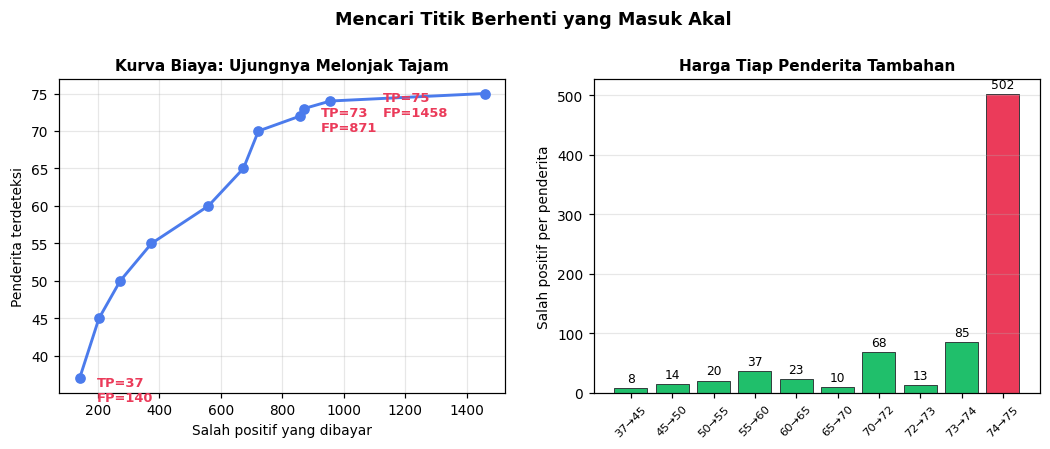

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.7))

fps = [r["fp"] for r in tabel]; tps = [r["tp"] for r in tabel]
ax[0].plot(fps, tps, "o-", color="#4b7bec", lw=1.9, ms=6)
for r in tabel:
    if r["tp"] in (37, 73, 75):
        ax[0].annotate(f'TP={r["tp"]}\nFP={r["fp"]}', xy=(r["fp"], r["tp"]),
                       xytext=(r["fp"]-330 if r["tp"]==75 else r["fp"]+55, r["tp"]-3),
                       fontsize=8.5, fontweight="bold", color="#eb3b5a")
ax[0].set_xlabel("Salah positif yang dibayar"); ax[0].set_ylabel("Penderita terdeteksi")
ax[0].set_title("Kurva Biaya: Ujungnya Melonjak Tajam", fontsize=10, fontweight="bold")
ax[0].grid(alpha=.3)

harga = [(tabel[i]["fp"]-tabel[i-1]["fp"])/(tabel[i]["tp"]-tabel[i-1]["tp"])
         for i in range(1, len(tabel))]
lbl = [f'{tabel[i-1]["tp"]}→{tabel[i]["tp"]}' for i in range(1, len(tabel))]
warna = ["#eb3b5a" if h > 200 else "#20bf6b" for h in harga]
b = ax[1].bar(lbl, harga, color=warna, edgecolor="#2d3436", linewidth=.6)
ax[1].bar_label(b, fmt="%.0f", fontsize=8, padding=2)
ax[1].set_ylabel("Salah positif per penderita")
ax[1].set_title("Harga Tiap Penderita Tambahan", fontsize=10, fontweight="bold")
ax[1].tick_params(axis="x", labelsize=7.5, rotation=45)
ax[1].grid(axis="y", alpha=.3)

fig.suptitle("Mencari Titik Berhenti yang Masuk Akal",
             fontsize=11.5, fontweight="bold", y=1.05)
plt.show()

## 3. Ambang Tidak Boleh Dicari dari Data Uji

Sampai di sini angka ambang masih dicari langsung dari data uji, dan itu keliru
secara metodologi: ambangnya jadi ikut menyesuaikan jawaban, sehingga hasil
evaluasinya tampak lebih baik daripada kenyataan.

Ambang yang benar dicari dari **prediksi out-of-fold pada data latih**. Masalahnya,
ambang dari data latih selalu melemah sedikit saat dipakai di data baru, jadi
targetnya perlu diberi margin. Berapa marginnya dicari di bawah ini.

In [5]:
oof = cross_val_predict(model, Xtr_e, y_train, cv=CV, method="predict_proba")[:, 1]
yt = y_train.to_numpy()

print(f"{'target OOF':>11} {'ambang':>8} | {'recall OOF':>11} {'recall uji':>11} "
      f"{'selisih':>9} | {'TP uji':>7} {'FP uji':>7}")
print("-" * 76)
for tgt in [0.90, 0.93, 0.95, 0.96, 0.97, 0.98, 0.99]:
    th = recall_target_threshold(yt, oof, tgt)
    r_oof = recall_score(yt, (oof >= th).astype(int))
    yp = (proba >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, yp).ravel()
    tanda = "  <-- dipilih" if abs(tgt - 0.98) < 1e-9 else ""
    print(f'{tgt:11.2f} {th:8.3f} | {r_oof:11.3f} {tp/tot:11.3f} '
          f'{r_oof-tp/tot:+9.3f} | {tp:7d} {fp:7d}{tanda}')

print()
print("Terlihat polanya: recall di data uji selalu lebih rendah daripada di OOF.")
print("Target OOF 0,93 hanya menghasilkan 0,84 di data uji (meleset jauh)")
print("Target OOF 0,98 menghasilkan 0,97, dan jumlah terdeteksi stroke sudah di kisaran 73 (bagus).")
print()
print("Maka TARGET_RECALL ditetapkan 0,98 pada prediksi out-of-fold,")
print("bukan angka yang dicomot dari hasil data uji.")

 target OOF   ambang |  recall OOF  recall uji   selisih |  TP uji  FP uji
----------------------------------------------------------------------------
       0.90    0.308 |       0.902       0.813    +0.089 |      61     575
       0.93    0.247 |       0.931       0.840    +0.091 |      63     609
       0.95    0.190 |       0.954       0.853    +0.101 |      64     659
       0.96    0.171 |       0.966       0.867    +0.099 |      65     680
       0.97    0.168 |       0.971       0.880    +0.091 |      66     685
       0.98    0.042 |       0.983       0.973    +0.009 |      73     905  <-- dipilih
       0.99    0.026 |       0.994       0.987    +0.008 |      74     972

Terlihat polanya: recall di data uji selalu lebih rendah daripada di OOF.
Target OOF 0,93 hanya menghasilkan 0,84 di data uji (meleset jauh)
Target OOF 0,98 menghasilkan 0,97, dan jumlah terdeteksi stroke sudah di kisaran 73 (bagus).

Maka TARGET_RECALL ditetapkan 0,98 pada prediksi out-of-fold,
bukan angka 

## 4. Kesimpulan Percobaan Hari Ini

Tiga hal yang didapat:

1. **Recall 1,0 tidak dapat dipakai.** Ambangnya jatuh ke 0,024 dan model menandai
   seluruh orang sehat, sehingga presisinya turun ke proporsi populasi dan
   keluarannya kehilangan makna.

2. **Titik berhenti yang wajar ada di sekitar 73 penderita.** Sampai titik itu
   harga per penderita tambahan masih stabil; setelahnya melonjak tajam sampai
   lebih dari 500 salah positif untuk 2 penderita terakhir.

3. **Ambang dicari dari prediksi out-of-fold dengan margin.** Karena ambang dari
   data latih selalu melemah di data baru, target dipatok 0,98 agar hasil di data
   uji mendarat di sekitar 0,97.

Fungsi `recall_target_threshold()` ditulis untuk menerapkan aturan ini, mengambil
ambang **tertinggi** yang recall-nya masih memenuhi target -- karena setiap
penurunan ambang di luar itu hanya menambah salah positif tanpa manfaat.

Pengujian hasilnya pada data uji dilakukan besok.